<a href="https://colab.research.google.com/github/siddhesh1503/Customer-Churn-Analysis/blob/main/ADS_EXPERIMENT9_SharkTankIndia_ARIMA_(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# EXPERIMENT 9 — ARIMA Time Series Forecasting
**Dataset:** Shark Tank India (Seasons 1–5) &nbsp;|&nbsp; **Target:** Total Deal Amount per Episode (₹ Lakhs)

| Metric | Value |
|---|---|
| Total Episodes | 213 |
| Date Range | 20 Dec 2021 – 05 Feb 2026 |
| Mean Deal / Episode | ₹149.22 L |
| Max Deal / Episode | ₹700 L |

In [ ]:
# ── Libraries ─────────────────────────────────────────────────────────────────
!pip install pmdarima -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.metrics import mean_squared_error
from pmdarima import auto_arima
from scipy import stats

print("Libraries loaded")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 13.1 MB/s eta 0:00:00
Libraries loaded


In [ ]:
# ── Load & Build Episode Time Series ─────────────────────────────────────────
df = pd.read_csv('Shark Tank India (1).csv')
df['Original Air Date'] = pd.to_datetime(df['Original Air Date'], format='%d-%b-%y', errors='coerce')

ep_ts = (
    df.groupby('Original Air Date')
    .agg(total_deal_amount=('Total Deal Amount', 'sum'))
    .sort_index()
)
ep_ts = ep_ts[ep_ts.index.notna()]

print("── Time Series Summary ──────────────────────────")
print(f"  Episodes   : {len(ep_ts)}")
print(f"  Date Range : {ep_ts.index.min().date()}  to  {ep_ts.index.max().date()}")
print(f"  Mean       : Rs. {ep_ts['total_deal_amount'].mean():.2f} L")
print(f"  Std Dev    : Rs. {ep_ts['total_deal_amount'].std():.2f} L")
print(f"  Min / Max  : Rs. {ep_ts['total_deal_amount'].min():.2f} L  /  Rs. {ep_ts['total_deal_amount'].max():.2f} L")

── Time Series Summary ──────────────────────────
  Episodes   : 213
  Date Range : 2021-12-20  to  2026-02-05
  Mean       : Rs. 149.22 L
  Std Dev    : Rs. 104.32 L
  Min / Max  : Rs. 0.00 L  /  Rs. 700.00 L


In [ ]:
# ── ADF Stationarity Test ─────────────────────────────────────────────────────
# p-value <= 0.05 : Stationary  |  p-value > 0.05 : Non-stationary

def adf_test(series, label):
    r = adfuller(series.dropna(), autolag='AIC')
    status = "STATIONARY" if r[1] <= 0.05 else "NON-STATIONARY"
    print(f"\n── ADF Test: {label} ─────────────────────")
    print(f"  ADF Statistic : {r[0]:.4f}")
    print(f"  p-value       : {r[1]:.4f}")
    print(f"  Lags Used     : {r[2]}   |   Obs: {r[3]}")
    print(f"  Critical (5%) : {r[4]['5%']:.4f}")
    print(f"  Result        : {status}")
    return r[1]

p_orig = adf_test(ep_ts['total_deal_amount'], "Original Series")


── ADF Test: Original Series ─────────────────────
  ADF Statistic : -7.5147
  p-value       : 0.0000
  Lags Used     : 1   |   Obs: 211
  Critical (5%) : -2.8753
  Result        : STATIONARY



── ADF Test: 1st Differenced Series ─────────────────────
  ADF Statistic : -7.5027
  p-value       : 0.0000
  Lags Used     : 13   |   Obs: 198
  Critical (5%) : -2.8763
  Result        : STATIONARY


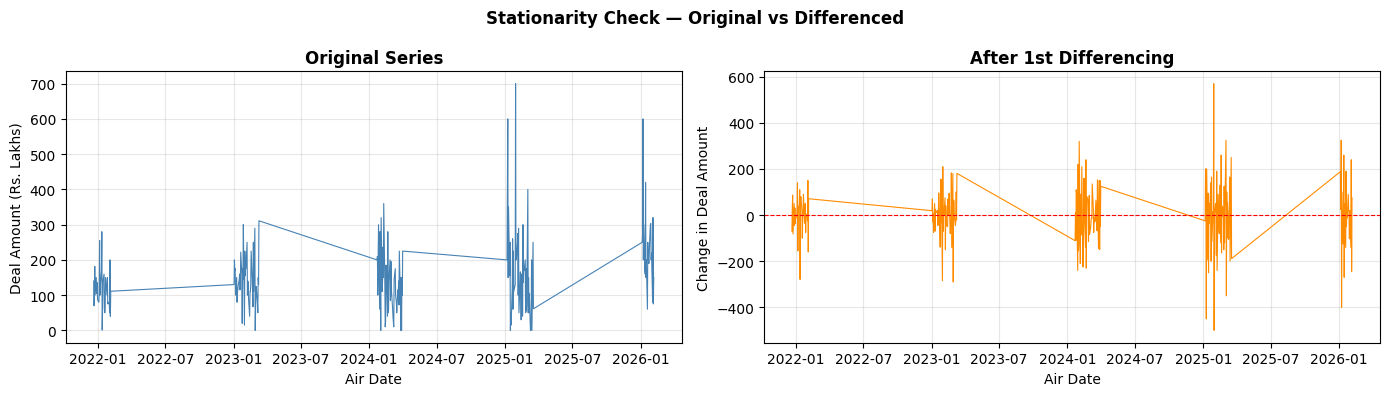

In [ ]:
# ── 1st Order Differencing ────────────────────────────────────────────────────

diff_series = ep_ts['total_deal_amount'].diff().dropna()
p_diff = adf_test(diff_series, "1st Differenced Series")

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(ep_ts.index, ep_ts['total_deal_amount'], color='steelblue', linewidth=0.8)
axes[0].set_title('Original Series', fontweight='bold')
axes[0].set_ylabel('Deal Amount (Rs. Lakhs)'); axes[0].grid(True, alpha=0.3)

axes[1].plot(diff_series.index, diff_series.values, color='darkorange', linewidth=0.8)
axes[1].axhline(0, color='red', linestyle='--', linewidth=0.8)
axes[1].set_title('After 1st Differencing', fontweight='bold')
axes[1].set_ylabel('Change in Deal Amount'); axes[1].grid(True, alpha=0.3)

for ax in axes: ax.set_xlabel('Air Date')
plt.suptitle('Stationarity Check — Original vs Differenced', fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()

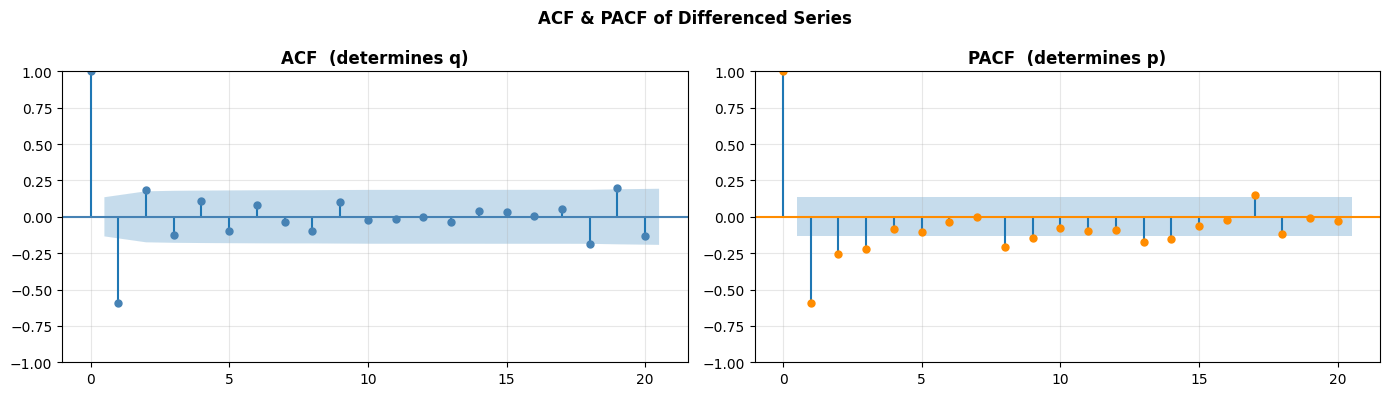

In [ ]:
# ── ACF & PACF Plots ──────────────────────────────────────────────────────────
# ACF -> q (MA order)  |  PACF -> p (AR order)

max_lags = min(20, len(diff_series) // 2 - 1)
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

plot_acf(diff_series,  lags=max_lags, ax=axes[0], color='steelblue', alpha=0.05)
axes[0].set_title('ACF  (determines q)', fontweight='bold')

plot_pacf(diff_series, lags=max_lags, ax=axes[1], color='darkorange', alpha=0.05)
axes[1].set_title('PACF  (determines p)', fontweight='bold')

for ax in axes: ax.grid(True, alpha=0.3)
plt.suptitle('ACF & PACF of Differenced Series', fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()

In [ ]:
# ── Auto ARIMA — Best (p, d, q) via AIC ──────────────────────────────────────

print("Fitting Auto ARIMA...\n")
auto_model = auto_arima(
    ep_ts['total_deal_amount'],
    start_p=0, max_p=5, start_q=0, max_q=5,
    d=None, seasonal=False, stepwise=True,
    information_criterion='aic', trace=True,
    error_action='ignore', suppress_warnings=True
)

best_order = auto_model.order
print(f"\n{'─'*42}")
print(f"  Best ARIMA Order : {best_order}")
print(f"  AIC              : {auto_model.aic():.4f}")
print(f"  p={best_order[0]} (AR)  |  d={best_order[1]} (diff)  |  q={best_order[2]} (MA)")
print(f"{'─'*42}")

Fitting Auto ARIMA...

Performing stepwise search to minimize aic
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=2702.065, Time=0.07 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=2613.415, Time=0.04 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=inf, Time=0.19 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=2700.065, Time=0.02 sec
 ARIMA(2,1,0)(0,0,0)[0] intercept   : AIC=2601.629, Time=0.13 sec
 ARIMA(3,1,0)(0,0,0)[0] intercept   : AIC=2592.985, Time=0.10 sec
 ARIMA(4,1,0)(0,0,0)[0] intercept   : AIC=2593.626, Time=0.22 sec
 ARIMA(3,1,1)(0,0,0)[0] intercept   : AIC=inf, Time=0.35 sec
 ARIMA(2,1,1)(0,0,0)[0] intercept   : AIC=inf, Time=0.20 sec
 ARIMA(4,1,1)(0,0,0)[0] intercept   : AIC=inf, Time=0.44 sec
 ARIMA(3,1,0)(0,0,0)[0]             : AIC=2590.987, Time=0.05 sec
 ARIMA(2,1,0)(0,0,0)[0]             : AIC=2599.631, Time=0.06 sec
 ARIMA(4,1,0)(0,0,0)[0]             : AIC=2591.630, Time=0.13 sec
 ARIMA(3,1,1)(0,0,0)[0]             : AIC=2569.377, Time=0.39 sec
 ARIMA(2,1,1)(0,0,0)[0]       

In [ ]:
# ── Train / Test Split — last 15 episodes as test ────────────────────────────

TEST_SIZE = 15
train = ep_ts['total_deal_amount'].iloc[:-TEST_SIZE]
test  = ep_ts['total_deal_amount'].iloc[-TEST_SIZE:]

print(f"  Train : {train.index[0].date()} to {train.index[-1].date()}   [{len(train)} episodes]")
print(f"  Test  : {test.index[0].date()}  to {test.index[-1].date()}    [{len(test)} episodes]")

  Train : 2021-12-20 to 2026-01-15   [198 episodes]
  Test  : 2026-01-16  to 2026-02-05    [15 episodes]


In [ ]:
# ── Fit ARIMA on Training Data ────────────────────────────────────────────────

model_fit = ARIMA(train, order=best_order).fit()
print(model_fit.summary())

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:      total_deal_amount   No. Observations:                  198
Model:                 ARIMA(2, 1, 1)   Log Likelihood               -1191.993
Date:                Tue, 31 Mar 2026   AIC                           2391.986
Time:                        17:27:38   BIC                           2405.119
Sample:                             0   HQIC                          2397.302
                                - 198                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.0602      0.070      0.856      0.392      -0.078       0.198
ar.L2          0.2290      0.084      2.712      0.007       0.064       0.395
ma.L1         -0.9835      0.027    -36.003      0.0

  Residual Mean : 9.2202   (ideal = 0)
  Residual Std  : 102.2780


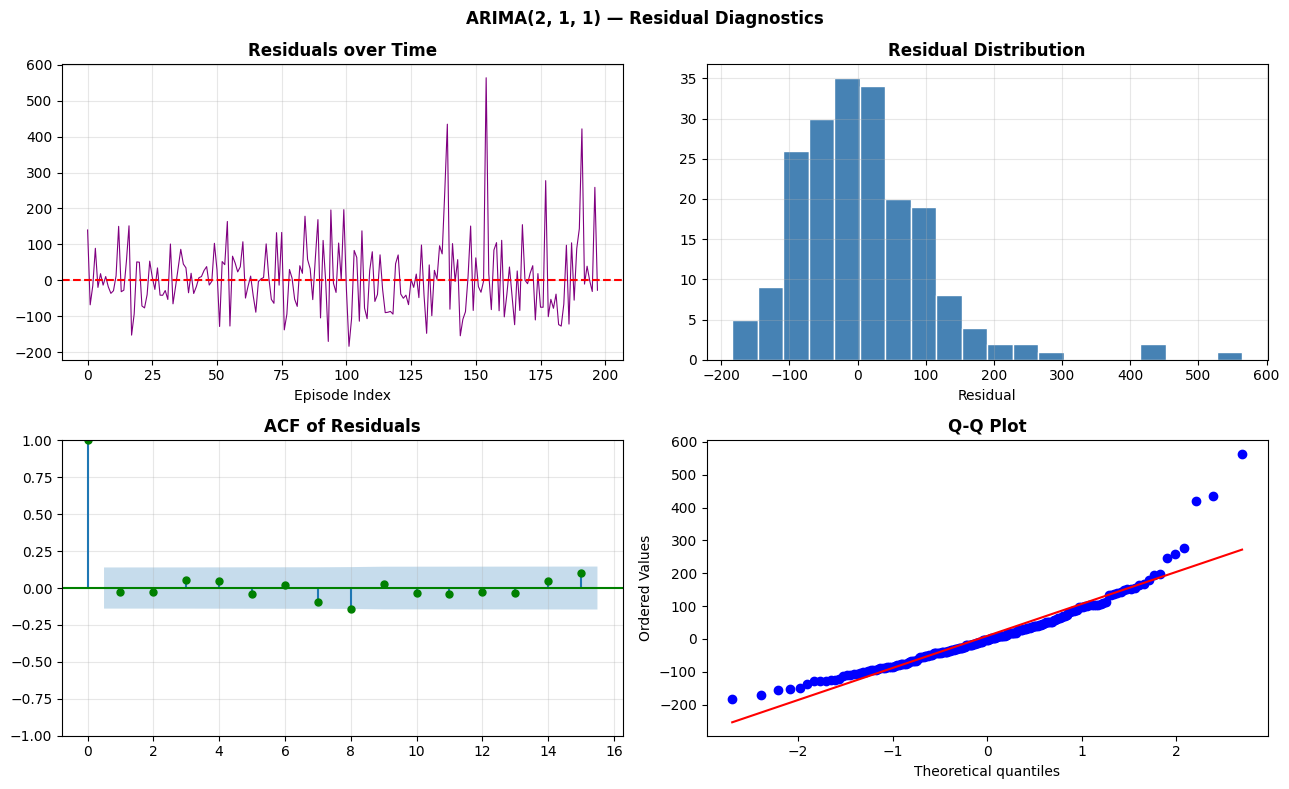

In [ ]:
# ── Residual Diagnostics ──────────────────────────────────────────────────────

residuals = model_fit.resid

print(f"  Residual Mean : {residuals.mean():.4f}   (ideal = 0)")
print(f"  Residual Std  : {residuals.std():.4f}")

fig, axes = plt.subplots(2, 2, figsize=(13, 8))

axes[0,0].plot(residuals.values, color='purple', linewidth=0.8)
axes[0,0].axhline(0, color='red', linestyle='--')
axes[0,0].set_title('Residuals over Time', fontweight='bold')
axes[0,0].set_xlabel('Episode Index'); axes[0,0].grid(True, alpha=0.3)

axes[0,1].hist(residuals, bins=20, color='steelblue', edgecolor='white')
axes[0,1].set_title('Residual Distribution', fontweight='bold')
axes[0,1].set_xlabel('Residual'); axes[0,1].grid(True, alpha=0.3)

plot_acf(residuals, lags=min(15, len(residuals)//2-1), ax=axes[1,0], color='green')
axes[1,0].set_title('ACF of Residuals', fontweight='bold'); axes[1,0].grid(True, alpha=0.3)

stats.probplot(residuals, dist='norm', plot=axes[1,1])
axes[1,1].set_title('Q-Q Plot', fontweight='bold')

plt.suptitle(f'ARIMA{best_order} — Residual Diagnostics', fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


   Air Date  Actual (Rs.L)  Forecast (Rs.L)  Error (Rs.L)  Abs Err %
16-Jan-2026          200.0           220.58        -20.58      10.29
19-Jan-2026           60.0           162.99       -102.99     171.64
20-Jan-2026          250.0           175.68         74.32      29.73
21-Jan-2026          200.0           163.26         36.74      18.37
22-Jan-2026          200.0           165.42         34.58      17.29
23-Jan-2026          190.0           162.70         27.30      14.37
26-Jan-2026          280.0           163.03        116.97      41.77
27-Jan-2026          300.0           162.43        137.57      45.86
28-Jan-2026          303.0           162.47        140.53      46.38
29-Jan-2026          200.0           162.33         37.67      18.83
30-Jan-2026          220.0           162.34         57.66      26.21
02-Feb-2026           80.0           162.30        -82.30     102.88
03-Feb-2026          320.0           162.30        157.70      49.28
04-Feb-2026           75.0        

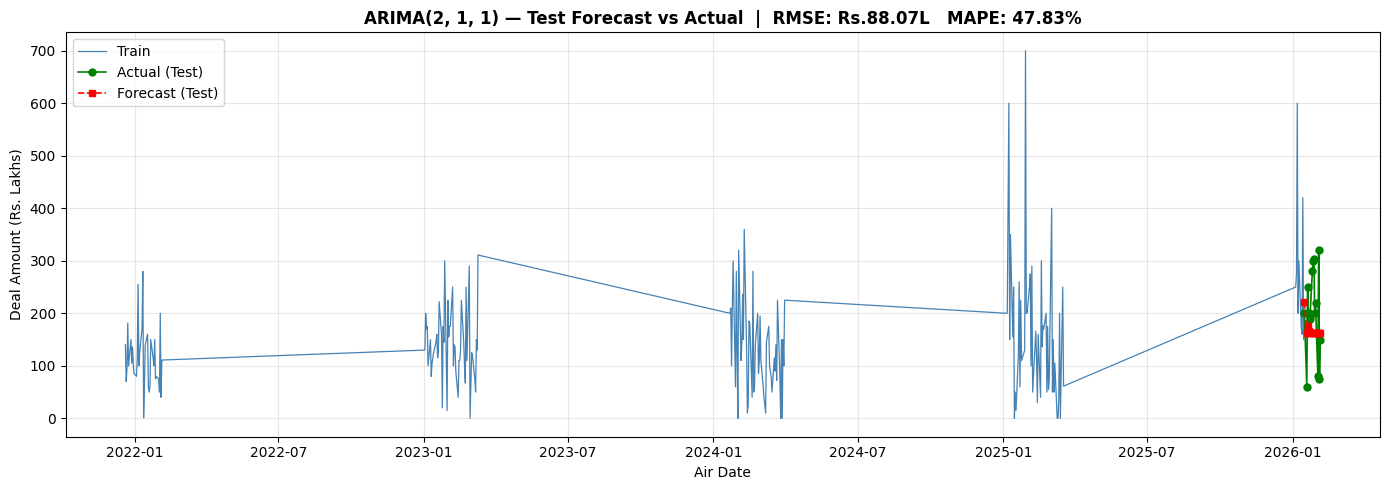

In [ ]:
# ── Test Forecast & Evaluation Metrics ───────────────────────────────────────

forecast_test = model_fit.forecast(steps=TEST_SIZE)
forecast_test.index = test.index

mse  = mean_squared_error(test, forecast_test)
rmse = np.sqrt(mse)
mape = np.mean(np.abs((test.values - forecast_test.values) / (test.values + 1e-9))) * 100

comp = pd.DataFrame({
    'Air Date'      : test.index.strftime('%d-%b-%Y'),
    'Actual (Rs.L)' : test.values.round(2),
    'Forecast (Rs.L)': forecast_test.values.round(2),
    'Error (Rs.L)'  : (test.values - forecast_test.values).round(2),
    'Abs Err %'     : (np.abs((test.values - forecast_test.values) / (test.values + 1e-9)) * 100).round(2)
})
print(comp.to_string(index=False))

print(f"\n── Evaluation Metrics ──────────────────────")
print(f"  MSE   : {mse:>12,.2f}")
print(f"  RMSE  : {rmse:>12,.2f}  Rs. Lakhs")
print(f"  MAPE  : {mape:>11,.2f} %")

plt.figure(figsize=(14, 5))
plt.plot(train.index, train.values, color='steelblue', lw=0.9, label='Train')
plt.plot(test.index, test.values,   color='green', marker='o', ms=5, lw=1.2, label='Actual (Test)')
plt.plot(forecast_test.index, forecast_test.values,
         color='red', linestyle='--', marker='s', ms=5, lw=1.2, label='Forecast (Test)')
plt.title(f'ARIMA{best_order} — Test Forecast vs Actual  |  RMSE: Rs.{rmse:.2f}L   MAPE: {mape:.2f}%',
          fontweight='bold')
plt.xlabel('Air Date'); plt.ylabel('Deal Amount (Rs. Lakhs)')
plt.legend(); plt.grid(True, alpha=0.3); plt.tight_layout(); plt.show()

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


── Next 20 Episode Forecast ─────────────────
 Episode        Date  Forecast (Rs.L)
       1 06-Feb-2026           149.46
       2 09-Feb-2026           166.95
       3 10-Feb-2026           167.77
       4 11-Feb-2026           171.90
       5 12-Feb-2026           172.31
       6 13-Feb-2026           173.30
       7 16-Feb-2026           173.45
       8 17-Feb-2026           173.69
       9 18-Feb-2026           173.74
      10 19-Feb-2026           173.80
      11 20-Feb-2026           173.81
      12 23-Feb-2026           173.83
      13 24-Feb-2026           173.83
      14 25-Feb-2026           173.83
      15 26-Feb-2026           173.83
      16 27-Feb-2026           173.84
      17 02-Mar-2026           173.84
      18 03-Mar-2026           173.84
      19 04-Mar-2026           173.84
      20 05-Mar-2026           173.84

  Avg Forecasted Deal/Episode : Rs. 171.73 L


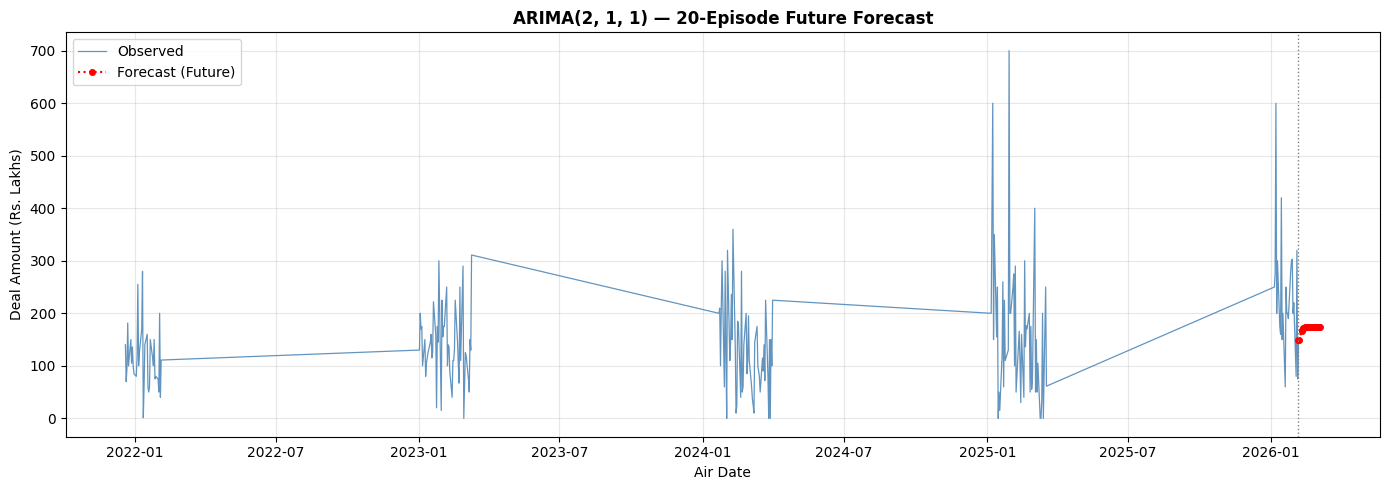

In [ ]:
# ── Future Forecast — Next 20 Episodes ───────────────────────────────────────
# Refit on full data

full_fit   = ARIMA(ep_ts['total_deal_amount'], order=best_order).fit()
future_fc  = full_fit.forecast(steps=20)
future_idx = pd.date_range(start=ep_ts.index[-1] + pd.Timedelta(days=1), periods=20, freq='B')
future_fc.index = future_idx

future_df = pd.DataFrame({
    'Episode'        : range(1, 21),
    'Date'           : future_idx.strftime('%d-%b-%Y'),
    'Forecast (Rs.L)': future_fc.values.round(2)
})
print("── Next 20 Episode Forecast ─────────────────")
print(future_df.to_string(index=False))
print(f"\n  Avg Forecasted Deal/Episode : Rs. {future_fc.mean():.2f} L")

plt.figure(figsize=(14, 5))
plt.plot(ep_ts.index, ep_ts['total_deal_amount'],
         color='steelblue', lw=0.9, alpha=0.85, label='Observed')
plt.plot([ep_ts.index[-1]] + list(future_idx),
         [ep_ts['total_deal_amount'].iloc[-1]] + list(future_fc.values),
         color='red', linestyle='dotted', marker='o', ms=4, lw=1.5, label='Forecast (Future)')
plt.axvline(ep_ts.index[-1], color='gray', linestyle=':', lw=1)
plt.title(f'ARIMA{best_order} — 20-Episode Future Forecast', fontweight='bold')
plt.xlabel('Air Date'); plt.ylabel('Deal Amount (Rs. Lakhs)')
plt.legend(); plt.grid(True, alpha=0.3); plt.tight_layout(); plt.show()

── Aman Gupta — Investment Series ──────────
  Episodes Invested : 116
  Total Invested    : Rs. 5,853.72 L
  Avg per Episode   : Rs. 50.46 L
  Min / Max         : Rs. 2.00 L  /  Rs. 300.00 L

── ADF Test: Aman Gupta Investment ─────────────────────
  ADF Statistic : -10.0572
  p-value       : 0.0000
  Lags Used     : 0   |   Obs: 115
  Critical (5%) : -2.8870
  Result        : STATIONARY

  Best ARIMA Order : (0, 1, 1)   AIC: 1202.4030

── Aman: Next 10 Episode Forecast ───────────
   09-Jan-2026 :  Rs. 72.36 L
   12-Jan-2026 :  Rs. 72.36 L
   13-Jan-2026 :  Rs. 72.36 L
   14-Jan-2026 :  Rs. 72.36 L
   15-Jan-2026 :  Rs. 72.36 L
   16-Jan-2026 :  Rs. 72.36 L
   19-Jan-2026 :  Rs. 72.36 L
   20-Jan-2026 :  Rs. 72.36 L
   21-Jan-2026 :  Rs. 72.36 L
   22-Jan-2026 :  Rs. 72.36 L


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


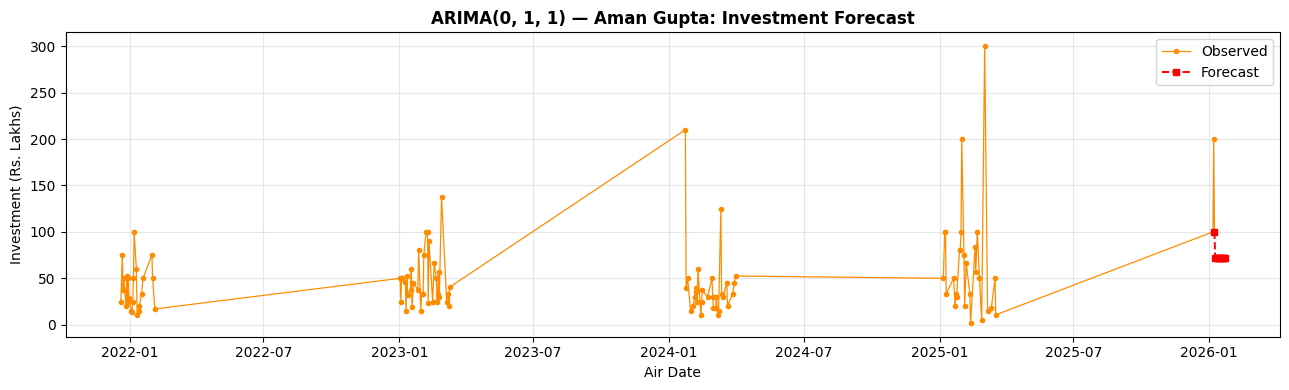


  Experiment 9 Complete — ARIMA Forecasting


In [ ]:
# ── Shark-Specific ARIMA — Aman Gupta ────────────────────────────────────────

shark_ts = (
    df[df['Aman Investment Amount'] > 0]
    .groupby('Original Air Date')['Aman Investment Amount']
    .sum().sort_index()
)

print("── Aman Gupta — Investment Series ──────────")
print(f"  Episodes Invested : {len(shark_ts)}")
print(f"  Total Invested    : Rs. {shark_ts.sum():,.2f} L")
print(f"  Avg per Episode   : Rs. {shark_ts.mean():.2f} L")
print(f"  Min / Max         : Rs. {shark_ts.min():.2f} L  /  Rs. {shark_ts.max():.2f} L")

adf_test(shark_ts, "Aman Gupta Investment")

shark_auto  = auto_arima(shark_ts, seasonal=False, stepwise=True,
                          suppress_warnings=True, trace=False)
shark_order = shark_auto.order
print(f"\n  Best ARIMA Order : {shark_order}   AIC: {shark_auto.aic():.4f}")

shark_fit = ARIMA(shark_ts, order=shark_order).fit()
shark_fc  = shark_fit.forecast(steps=10)
shark_idx = pd.date_range(start=shark_ts.index[-1] + pd.Timedelta(days=1), periods=10, freq='B')
shark_fc.index = shark_idx

print("\n── Aman: Next 10 Episode Forecast ───────────")
for dt, v in zip(shark_idx, shark_fc.values):
    print(f"   {dt.strftime('%d-%b-%Y')} :  Rs. {v:,.2f} L")

plt.figure(figsize=(13, 4))
plt.plot(shark_ts.index, shark_ts.values, color='darkorange', lw=0.9,
         marker='o', ms=3, label='Observed')
plt.plot([shark_ts.index[-1]] + list(shark_idx),
         [shark_ts.values[-1]] + list(shark_fc.values),
         color='red', linestyle='--', marker='s', ms=4, lw=1.4, label='Forecast')
plt.title(f'ARIMA{shark_order} — Aman Gupta: Investment Forecast', fontweight='bold')
plt.xlabel('Air Date'); plt.ylabel('Investment (Rs. Lakhs)')
plt.legend(); plt.grid(True, alpha=0.3); plt.tight_layout(); plt.show()

print("\n" + "="*50)
print("  Experiment 9 Complete — ARIMA Forecasting")
print("="*50)